In [148]:
#importing the neccessary libraries for task 1
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
#loading the dataset
machines = pd.read_csv('task1.csv')

In [150]:
machines.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [151]:
machines.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [152]:
#A brief summary of the dataset
machines.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [153]:
#showing the number of features and number of samples
machines.shape

(10000, 14)

In [126]:
#We can further inspect our dataset 
machines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

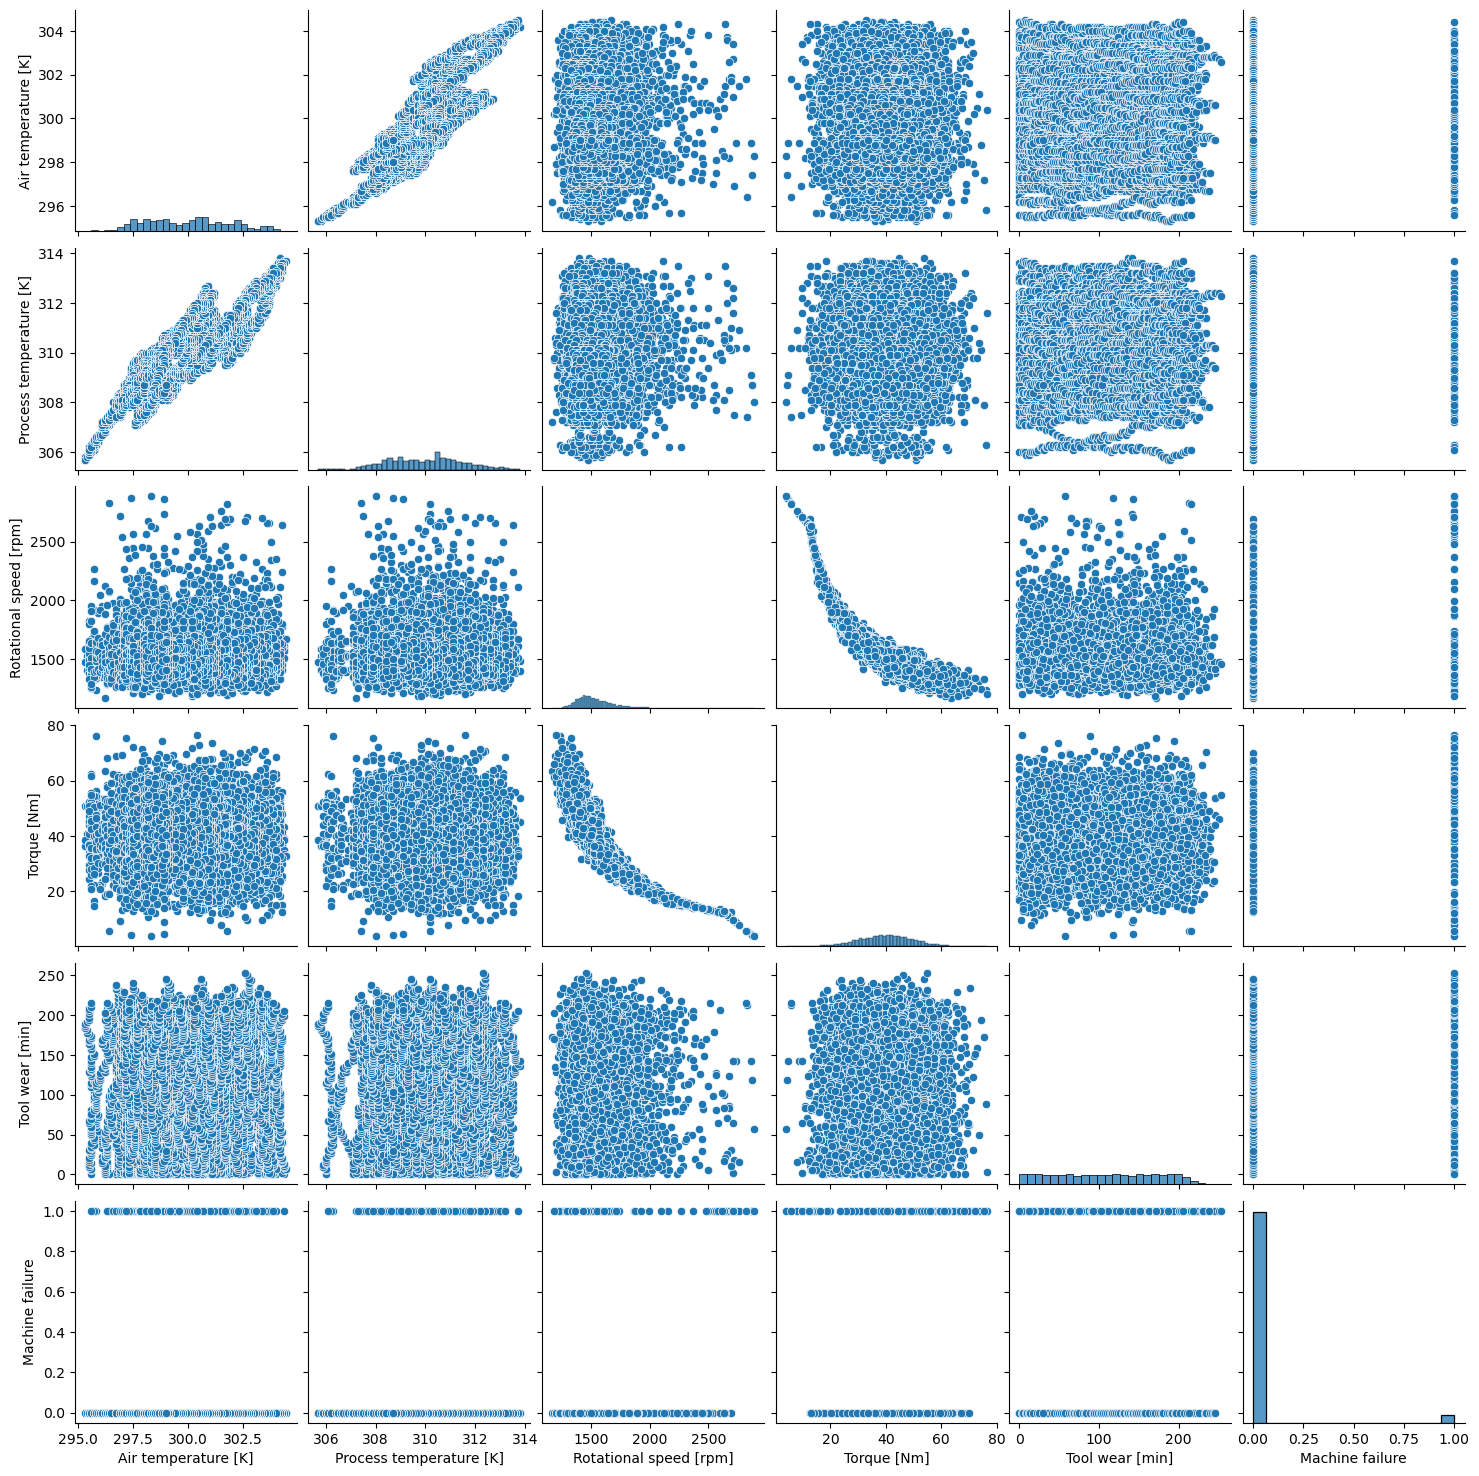

In [154]:
# Select all rows and include column 7 plus the other columns you want
# Assuming column indices are 0-based and you want columns 2,3,4,5,6 compared with column 7
selected_columns = [2, 3, 4, 5, 6, 7,8]  # Include column 7 and others
plot_data = machines.iloc[:, selected_columns]  # Select all rows and specified columns

# Create the pairplot
sns.pairplot(plot_data)

# If you specifically want to focus on relationships with column 7
# You can also use the vars and hue parameters
# column_names = plot_data.columns.tolist()
# sns.pairplot(plot_data, x_vars=column_names[:-1], y_vars=[column_names[-1]])

In [155]:
#checking for any class imbalances in the machine learning column
machines['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [156]:
#we convert the type column into numerical values
machines['Type']= machines['Type'].replace(['M','L','H'],[0,1,2])

/var/folders/zq/hchz2zns6jj2yg40_4xpbdnh0000gn/T/ipykernel_30490/3366506165.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  machines['Type']= machines['Type'].replace(['M','L','H'],[0,1,2])


In [157]:
#checking the values in each of the types
machines['Type'].value_counts()

Type
1    6000
0    2997
2    1003
Name: count, dtype: int64

In [158]:
machines.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [159]:
#defining the features we need to predict machine failure
x = machines.iloc[:,[2,3,4,5,6,7]].values
y = machines.iloc[:,8].values

In [160]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(x)

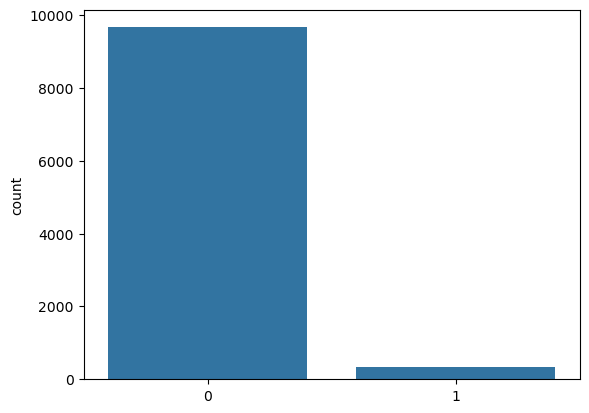

In [161]:
#We are trying to visualize the class imbalance in our outputs.
sns.countplot(x=y)
plt.show()

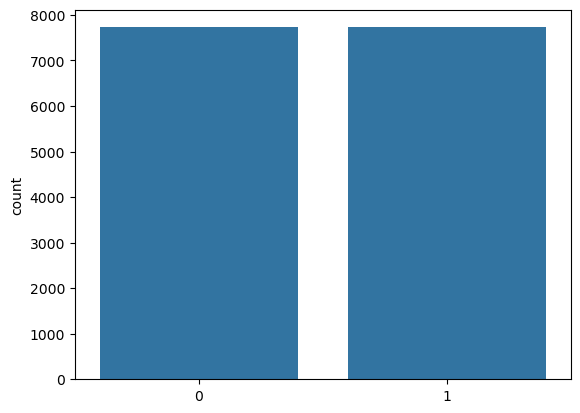

In [163]:
#we split the dataset into training data and testing data 

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify = y, random_state=0)

#we address our class imbalance using SMOTE to create synthetic data
from imblearn.over_sampling import SMOTE

resampler = SMOTE(random_state=0)
x_train_smote, y_train_smote = resampler.fit_resample(x_train, y_train)
#We plot the two outputs to see if there is stilla class imbalance
sns.countplot(x=y_train_smote)
plt.show()


In [164]:
#We use decision tree classification al
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state=0)
classifier.fit(x_train_smote,y_train_smote)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [165]:
#we are defining y_pred as the predicted values from the algorithms and printing the values
y_pred = classifier.predict(x_test)
print(y_pred)

[0 0 0 ... 0 0 1]


In [166]:
#printing values of y in the test dataset so we can compare with the predicted values
print(y_test)

[0 0 0 ... 0 0 0]


In [167]:
#creating a classification report and confusion matrix to check the performance of our algorithm
from sklearn import metrics
acc = metrics.accuracy_score(y_test,y_pred)
print('accuracy:%.2f\n\n'%(acc))
cm = metrics.confusion_matrix(y_test,y_pred)
print('confusion Matrix:')
print(cm,'\n\n')
print('-------------------------------')
result=metrics.classification_report(y_test,y_pred)
print('Classification Report:\n')
print(result)

accuracy:0.96


confusion Matrix:
[[1873   59]
 [  19   49]] 


-------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.45      0.72      0.56        68

    accuracy                           0.96      2000
   macro avg       0.72      0.85      0.77      2000
weighted avg       0.97      0.96      0.97      2000



<function matplotlib.pyplot.show(close=None, block=None)>

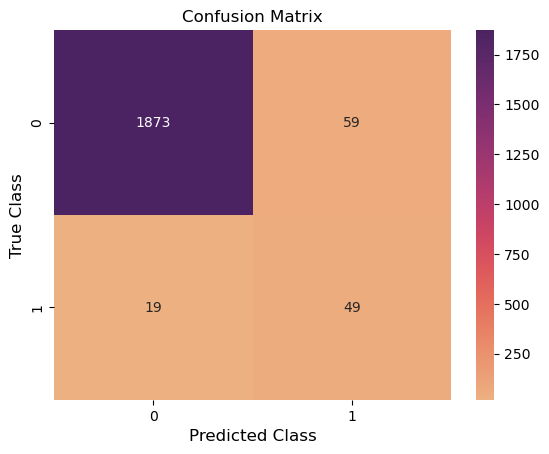

In [168]:
#creating a heatmap so we can see the predicted output compared with the actual output
ax = sns.heatmap(cm, cmap='flare',annot=True, fmt='d')
plt.xlabel("Predicted Class", fontsize = 12)
plt.ylabel("True Class", fontsize = 12)
plt.title("Confusion Matrix", fontsize = 12)

plt.show